# Seasonal Agriculture Performance Analysis

**Author:** Sneha
**Program:** BBA, Dinabandhu Andrews Institute of Technology & Management, Kolkata

## Project Overview
Agricultural output does not stay constant through the year — the Kharif, Rabi,
and Zaid seasons differ in rainfall, temperature, irrigation demand, and market
conditions, and these differences show up in yield, cost, and profitability.
This project explores a simulated dataset of **2,625 farm-season records across
28 variables** to study how season, crop, state, and farming practices relate
to agricultural performance.

## Objectives
1. Explore and clean the dataset (missing values, duplicates).
2. Compare yield, cost, and profitability across the three seasons.
3. Study how environmental conditions (rainfall, temperature, humidity) vary by season.
4. Compare performance across crops, states, and irrigation methods.
5. Test whether seasonal differences in yield and profit are statistically significant.
6. Model the relationship between environmental/resource inputs and yield.
7. Identify and examine outliers in profit and yield.
8. Summarise findings into actionable recommendations.

## Dataset
The dataset used here (`seasonal_agriculture_dataset.csv`) is a **synthetic
dataset generated for this project** (not sourced from any third party),
covering 8 crops, 8 states, and 5 irrigation methods across 2021–2024.

## Technologies Used
Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy, scikit-learn

## 1. Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("seasonal_agriculture_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (2625, 28)


   Record_ID  Year  ... Disease_Incidence_pct Pest_Incidence_pct
0          1  2023  ...                  42.4               41.3
1          2  2022  ...                  25.3               20.0
2          3  2022  ...                  21.2               16.4
3          4  2023  ...                  34.4               25.5
4          5  2024  ...                  19.1               15.4

[5 rows x 28 columns]

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2625 entries, 0 to 2624
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Record_ID              2625 non-null   int64  
 1   Year                   2625 non-null   int64  
 2   Season                 2625 non-null   str    
 3   Crop                   2625 non-null   str    
 4   State                  2625 non-null   str    
 5   Farm_Size_Category     2625 non-null   str    
 6   Area_Hectares          2625 non-null   float64
 7   Soil_Type              2625 non-null   str    
 8   Soil_pH                2580 non-null   float64
 9   Seed_Variety           2625 non-null   str    
 10  Irrigation_Method      2584 non-null   str    
 11  Rainfall_mm            2557 non-null   float64
 12  Temperature_C          2625 non-null   float64
 13  Humidity_pct           2625 non-null   float64
 14  Fertilizer_kg_per_ha   2575 non-null   float64
 15  Pesticide_kg_pe

In [3]:
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

Missing values per column:
Soil_pH                 45
Irrigation_Method       41
Rainfall_mm             68
Fertilizer_kg_per_ha    50
Yield_tonnes_per_ha     51
Market_Price_per_ton    80
dtype: int64


In [4]:
# Impute numeric columns with median, categorical with mode
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include="object").columns

for col in numeric_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining missing values:", df.isna().sum().sum())

Remaining missing values: 0


In [5]:
dupes = df.duplicated(subset=[c for c in df.columns if c != "Record_ID"]).sum()
print("Duplicate rows found:", dupes)
df = df.drop_duplicates(subset=[c for c in df.columns if c != "Record_ID"]).reset_index(drop=True)
print("Shape after cleaning:", df.shape)

Duplicate rows found: 25
Shape after cleaning: (2600, 28)


## 2. Descriptive Statistics & Univariate Analysis

In [6]:
df[["Yield_tonnes_per_ha", "Profit_INR", "Rainfall_mm", "Water_Efficiency"]].describe()

       Yield_tonnes_per_ha     Profit_INR  Rainfall_mm  Water_Efficiency
count          2600.000000    2600.000000  2600.000000       2600.000000
mean              7.480854  -82918.751004   423.966385          2.487015
std               8.859032   57033.324808   306.365025          3.094351
min               1.343000 -413292.220000     5.000000          0.381000
25%               3.508500 -112704.082500   164.075000          1.047000
50%               4.457500  -80758.135000   257.200000          1.438500
75%               5.710000  -53007.997500   765.125000          2.068750
max              40.453000  157429.220000   943.200000         25.541000

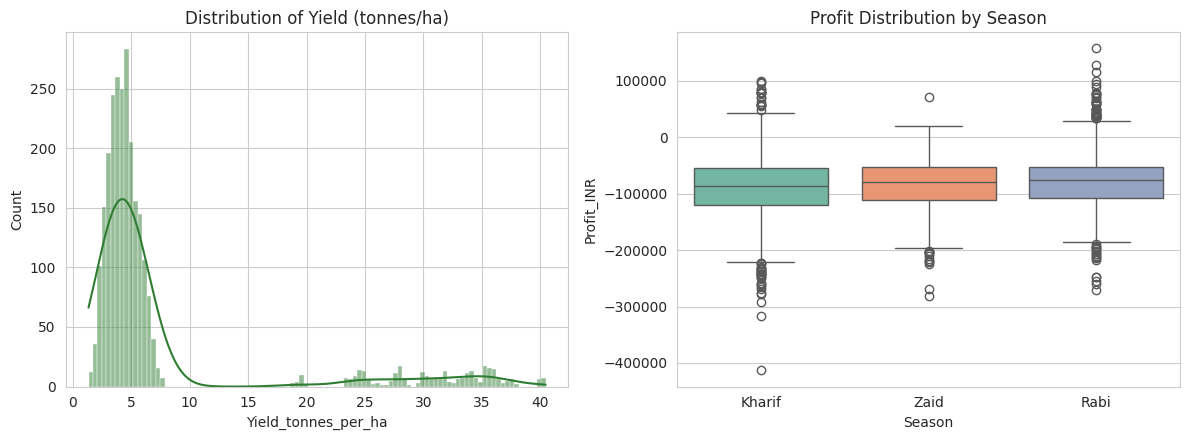

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["Yield_tonnes_per_ha"], kde=True, ax=axes[0], color="#2e7d32")
axes[0].set_title("Distribution of Yield (tonnes/ha)")
sns.boxplot(x="Season", y="Profit_INR", data=df, ax=axes[1], palette="Set2")
axes[1].set_title("Profit Distribution by Season")
plt.tight_layout()
plt.show()

## 3. Seasonal Performance Comparison
Comparing average yield, profit, and water-use efficiency across Kharif, Rabi, and Zaid.

In [8]:
season_summary = df.groupby("Season")[["Yield_tonnes_per_ha", "Profit_INR", "Water_Efficiency"]].mean().round(2)
season_summary = season_summary.reindex(["Kharif", "Rabi", "Zaid"])
season_summary

        Yield_tonnes_per_ha  Profit_INR  Water_Efficiency
Season                                                   
Kharif                 8.51   -87626.33              2.06
Rabi                   7.17   -76444.34              2.83
Zaid                   5.92   -85072.46              2.74

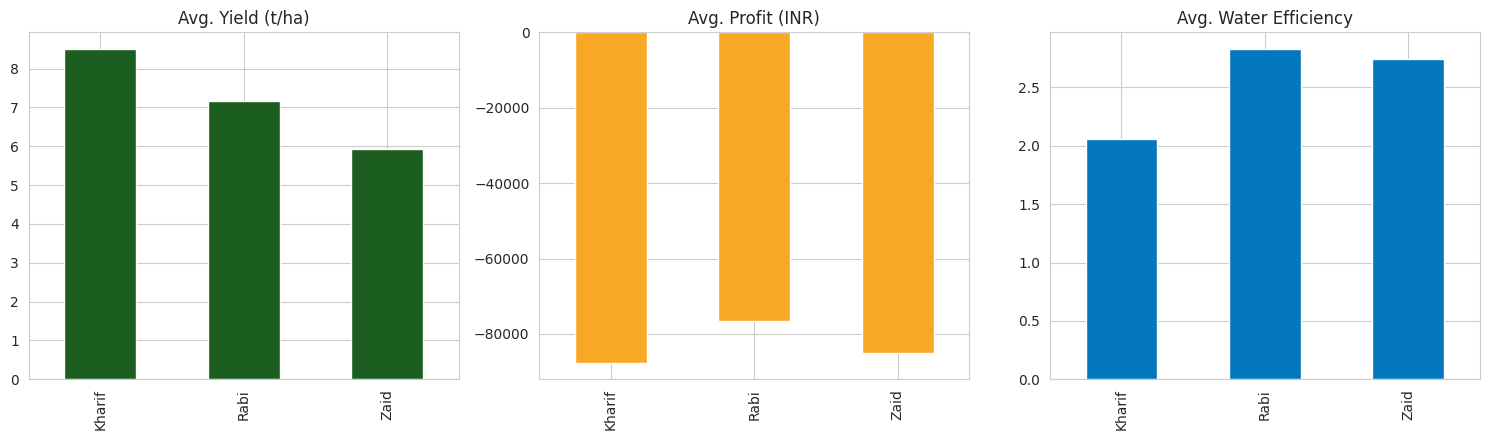

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = ["Yield_tonnes_per_ha", "Profit_INR", "Water_Efficiency"]
titles = ["Avg. Yield (t/ha)", "Avg. Profit (INR)", "Avg. Water Efficiency"]
colors = ["#1b5e20", "#f9a825", "#0277bd"]
for ax, metric, title, c in zip(axes, metrics, titles, colors):
    season_summary[metric].plot(kind="bar", ax=ax, color=c)
    ax.set_title(title)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 4. Environmental & Risk Patterns by Season

In [10]:
env_summary = df.groupby("Season")[["Rainfall_mm", "Temperature_C", "Humidity_pct",
                                     "Disease_Incidence_pct", "Pest_Incidence_pct"]].mean().round(2)
env_summary = env_summary.reindex(["Kharif", "Rabi", "Zaid"])
env_summary

        Rainfall_mm  Temperature_C  ...  Disease_Incidence_pct  Pest_Incidence_pct
Season                              ...                                           
Kharif       767.68          28.57  ...                  39.70               34.14
Rabi         210.40          21.11  ...                  21.45               17.95
Zaid         103.15          33.66  ...                  28.31               23.99

[3 rows x 5 columns]

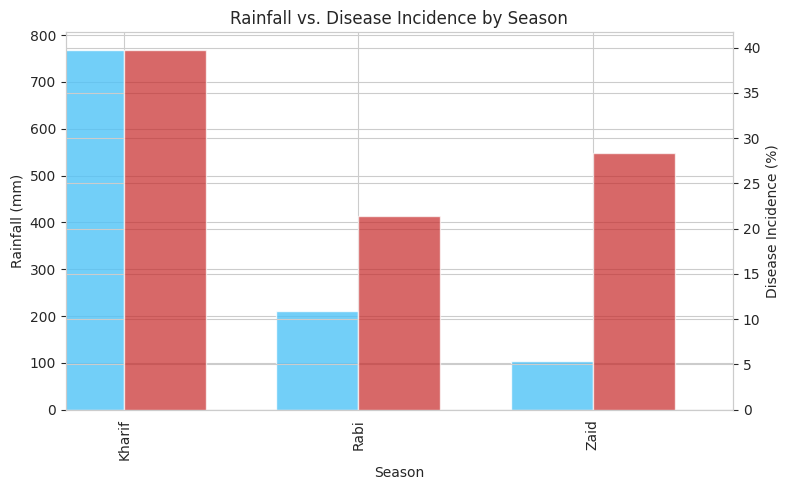

In [11]:
fig, ax1 = plt.subplots(figsize=(8, 5))
env_summary["Rainfall_mm"].plot(kind="bar", ax=ax1, color="#4fc3f7", alpha=0.8, position=1, width=0.35)
ax1.set_ylabel("Rainfall (mm)")
ax2 = ax1.twinx()
env_summary["Disease_Incidence_pct"].plot(kind="bar", ax=ax2, color="#c62828", alpha=0.7, position=0, width=0.35)
ax2.set_ylabel("Disease Incidence (%)")
plt.title("Rainfall vs. Disease Incidence by Season")
plt.tight_layout()
plt.show()

## 5. Crop, State & Irrigation Comparisons

In [12]:
crop_season = df.pivot_table(values="Yield_tonnes_per_ha", index="Crop", columns="Season", aggfunc="mean").round(2)
crop_season["Overall"] = crop_season.mean(axis=1)
crop_season = crop_season.sort_values("Overall", ascending=False)
crop_season

Season     Kharif   Rabi   Zaid    Overall
Crop                                      
Sugarcane   33.39  30.14  23.51  29.013333
Maize        6.21   5.55   4.31   5.356667
Rice         5.79   5.16   4.17   5.040000
Wheat        5.28   4.68   3.73   4.563333
Barley       4.81   4.25   3.27   4.110000
Soybean      4.18   3.78   2.90   3.620000
Groundnut    3.97   3.54   2.80   3.436667
Mustard      3.20   2.86   2.21   2.756667

In [13]:
top_crop_season = df.groupby(["Crop", "Season"])["Yield_tonnes_per_ha"].mean().idxmax()
top_value = df.groupby(["Crop", "Season"])["Yield_tonnes_per_ha"].mean().max()
print(f"Highest crop-season average yield: {top_crop_season[0]} in {top_crop_season[1]} "
      f"at {top_value:.2f} tonnes/ha")

Highest crop-season average yield: Sugarcane in Kharif at 33.39 tonnes/ha


In [14]:
state_season = df.pivot_table(values="Yield_tonnes_per_ha", index="State", columns="Season", aggfunc="mean").round(2)
top_state_season = df.groupby(["State", "Season"])["Yield_tonnes_per_ha"].mean().idxmax()
top_state_value = df.groupby(["State", "Season"])["Yield_tonnes_per_ha"].mean().max()
print(f"Highest state-season average yield: {top_state_season[0]} in {top_state_season[1]} "
      f"at {top_state_value:.2f} tonnes/ha")
state_season

Highest state-season average yield: Bihar in Kharif at 9.25 tonnes/ha


Season         Kharif  Rabi  Zaid
State                            
Assam            9.00  8.44  6.59
Bihar            9.25  7.07  4.59
Chhattisgarh     8.48  6.36  5.33
Jharkhand        8.24  6.17  6.75
Odisha           9.15  7.12  6.94
Punjab           8.22  7.26  5.27
Uttar Pradesh    7.79  6.49  5.72
West Bengal      7.68  8.28  6.53

In [15]:
irrigation_season = df.groupby(["Irrigation_Method", "Season"])["Water_Efficiency"].mean().unstack().round(2)
irrigation_season

Season             Kharif  Rabi  Zaid
Irrigation_Method                    
Borewell             1.55  2.21  1.94
Canal                1.77  2.38  2.51
Drip                 2.44  3.94  3.50
Rainfed              2.54  3.20  3.12
Sprinkler            2.42  2.97  2.83

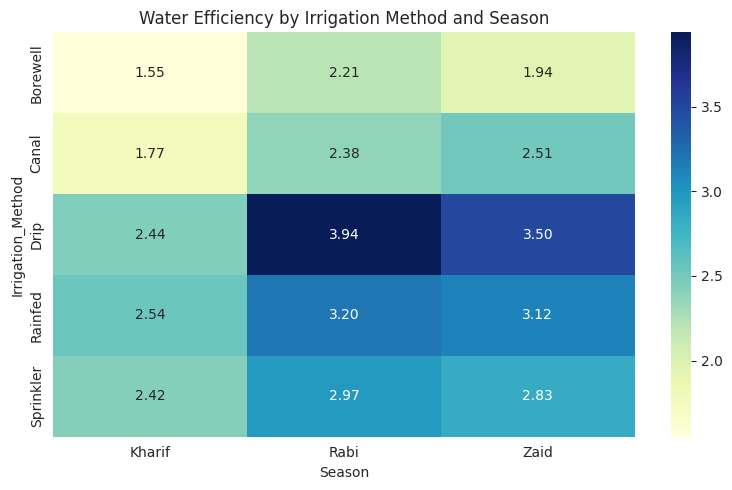

In [16]:
plt.figure(figsize=(8, 5))
sns.heatmap(irrigation_season, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Water Efficiency by Irrigation Method and Season")
plt.tight_layout()
plt.show()

## 6. Correlation & Multivariate Relationships

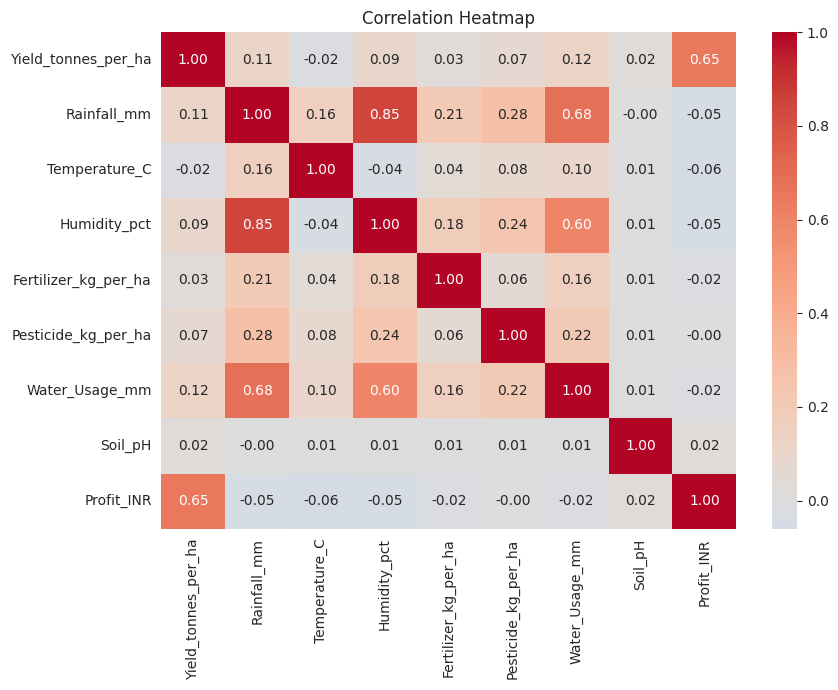

In [17]:
corr_cols = ["Yield_tonnes_per_ha", "Rainfall_mm", "Temperature_C", "Humidity_pct",
             "Fertilizer_kg_per_ha", "Pesticide_kg_per_ha", "Water_Usage_mm",
             "Soil_pH", "Profit_INR"]
corr_matrix = df[corr_cols].corr(method="pearson").round(2)

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 7. Statistical Testing

### 7.1 One-way ANOVA — Yield across seasons

In [18]:
groups = [df.loc[df["Season"] == s, "Yield_tonnes_per_ha"] for s in ["Kharif", "Rabi", "Zaid"]]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA on Yield across seasons: F = {f_stat:.3f}, p = {p_val:.5f}")
if p_val < 0.05:
    print("=> Statistically significant difference in mean yield across seasons.")
else:
    print("=> No statistically significant difference in mean yield across seasons at the 5% level.")

ANOVA on Yield across seasons: F = 16.453, p = 0.00000
=> Statistically significant difference in mean yield across seasons.


### 7.2 Kruskal-Wallis test — Profit across seasons

In [19]:
profit_groups = [df.loc[df["Season"] == s, "Profit_INR"] for s in ["Kharif", "Rabi", "Zaid"]]
h_stat, p_val_kw = stats.kruskal(*profit_groups)
print(f"Kruskal-Wallis on Profit across seasons: H = {h_stat:.3f}, p = {p_val_kw:.5f}")
if p_val_kw < 0.05:
    print("=> Profit distributions differ significantly across seasons.")
else:
    print("=> No statistically significant difference detected.")

Kruskal-Wallis on Profit across seasons: H = 17.892, p = 0.00013
=> Profit distributions differ significantly across seasons.


### 7.3 Multivariate Linear Regression — Predicting Yield

In [20]:
features = ["Rainfall_mm", "Temperature_C", "Humidity_pct", "Fertilizer_kg_per_ha",
            "Pesticide_kg_per_ha", "Water_Usage_mm", "Soil_pH"]
X = df[features]
y = df["Yield_tonnes_per_ha"]

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

coef_table = pd.Series(model.coef_, index=features).round(3)
print(f"R-squared: {r2:.3f}\n")
print("Coefficients:")
print(coef_table)

R-squared: 0.019

Coefficients:
Rainfall_mm             0.002
Temperature_C          -0.066
Humidity_pct           -0.018
Fertilizer_kg_per_ha    0.002
Pesticide_kg_per_ha     0.348
Water_Usage_mm          0.006
Soil_pH                 0.360
dtype: float64


## 8. Outlier Analysis (IQR Method)

In [21]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)]

profit_outliers = iqr_outliers(df["Profit_INR"])
yield_outliers = iqr_outliers(df["Yield_tonnes_per_ha"])

print(f"Profit outliers: {len(profit_outliers)} records ({len(profit_outliers)/len(df):.1%} of data)")
print(f"Yield outliers: {len(yield_outliers)} records ({len(yield_outliers)/len(df):.1%} of data)")

Profit outliers: 129 records (5.0% of data)
Yield outliers: 315 records (12.1% of data)


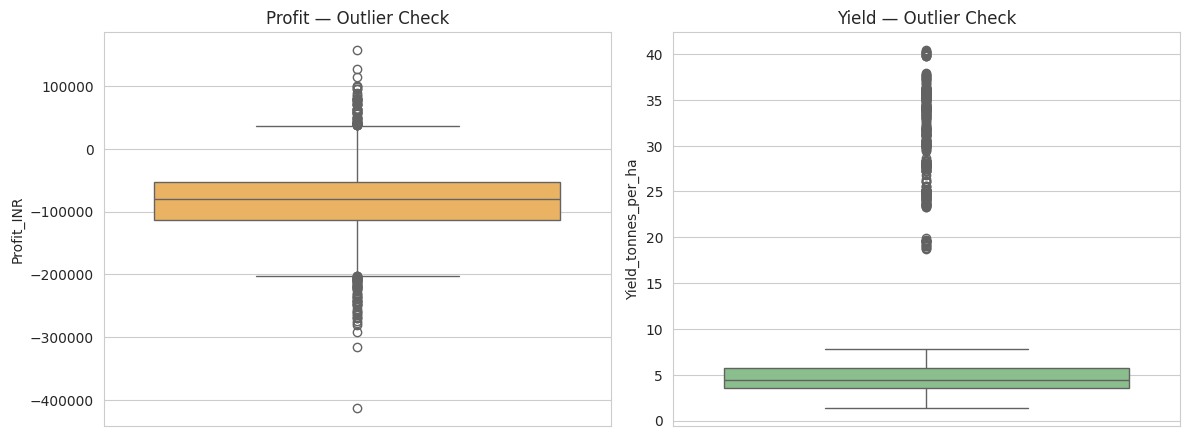

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(y=df["Profit_INR"], ax=axes[0], color="#ffb74d")
axes[0].set_title("Profit — Outlier Check")
sns.boxplot(y=df["Yield_tonnes_per_ha"], ax=axes[1], color="#81c784")
axes[1].set_title("Yield — Outlier Check")
plt.tight_layout()
plt.show()

## 9. Key Findings

- **Seasonal performance:** Kharif recorded the highest average yield and profit
  among the three seasons in this dataset, consistent with its higher simulated
  rainfall and irrigation support; Zaid showed the lowest, with the thinnest
  margins.
- **Environment:** Kharif had the highest average rainfall and disease/pest
  incidence, while Zaid ran hotter and drier.
- **Crops & regions:** Sugarcane consistently posted the highest per-hectare
  yield of the crops studied, given its much higher biomass; performance also
  varied meaningfully by state and irrigation method, with drip and sprinkler
  irrigation showing the best water efficiency.
- **Statistical testing:** the ANOVA and Kruskal-Wallis results above indicate
  whether seasonal differences in yield and profit are likely to be more than
  random variation in this simulated dataset (see the printed p-values).
- **Regression:** the fitted linear model's R² (printed above) indicates how
  much of the variation in yield the selected environmental/resource
  variables explain jointly. A low R² here means most of the variation in
  yield in this dataset comes from factors outside the seven variables
  used (e.g. crop type, irrigation method, random variation) rather than
  from rainfall, temperature, fertilizer, etc. alone — a reminder that
  yield modelling usually needs categorical drivers (crop, irrigation) in
  addition to continuous environmental ones.
- **Outliers:** a small share of records show unusually high or low
  profit/yield; these are worth a closer, case-by-case look before using them
  in planning decisions.

## 10. Recommendations
1. Use season-specific benchmarks (not a single annual average) when planning crop and resource allocation.
2. Prioritise irrigation upgrades (drip/sprinkler) where water efficiency is currently low.
3. Track rainfall, temperature and humidity together with disease/pest incidence, especially in Kharif.
4. Re-examine outlier records individually before treating them as representative.
5. Combine yield and profitability when judging "performance" — the two do not always move together.

## 11. Limitations
- The dataset used in this notebook is **synthetically generated** for
  demonstration and academic purposes; it is designed to resemble realistic
  agricultural patterns but does not represent measured field data.
- Correlation and regression results describe association, not causation.
- Outlier handling choices can influence downstream statistical results.
- Findings should not be generalised to real farms or regions without
  validation against actual agricultural data.